In [35]:
import pandas as pd

train_data = pd.read_csv('Data/final_train.csv', index_col=0)
test_data = pd.read_csv('Data/final_test.csv', index_col=0)

train_x, train_y = train_data.drop('SalePrice', axis=1), train_data['SalePrice']
test_x, test_y = test_data.drop('SalePrice', axis=1), test_data['SalePrice']

train_x

,Foundation_PConc,GarageType_Detchd,GarageType_Attchd,Exterior2nd_VinylSd,MSZoning_RM,Foundation_CBlock,Neighborhood_NAmes,MSZoning_RL,Exterior1st_VinylSd,SaleType_New,...,Bsmt_index,Garage_index,Condition_index,Living_Area,OpenSF,Luxury_index,Comf_idx,FullBath,LotFrontage,YearBuilt
741,True,False,True,False,False,False,False,True,False,False,...,5,6,60.000,35.628359,3.590896,3.875578,9.414997,0.911265,15.604698,1995
865,False,True,False,False,False,True,True,True,False,False,...,3,4,37.500,36.329019,0.000000,0.154925,13.298420,0.911265,26.535234,1949
339,True,False,True,False,False,False,False,True,False,True,...,7,6,30.000,42.542947,3.468843,5.547298,13.581823,1.712883,25.179280,2005
192,False,False,False,False,True,True,False,False,False,False,...,2,0,46.875,37.573278,5.672260,0.000000,17.129117,0.911265,36.667137,1912
203,False,False,True,False,False,True,True,True,False,False,...,4,5,15.000,34.079853,3.168412,4.371354,14.938750,0.911265,31.425563,1964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,True,False,True,False,False,False,True,False,False,False,...,7,6,60.000,34.165046,8.774702,4.159288,9.562460,1.712883,17.186882,1998
1185,False,True,False,True,False,True,True,True,True,False,...,6,4,17.500,33.420319,9.100719,4.004645,14.336896,0.911265,30.469668,1965
1167,True,False,True,True,False,False,False,True,True,False,...,9,5,10.000,36.102675,10.752007,4.472627,14.451533,1.712883,29.826615,2003
517,True,False,True,True,False,False,False,True,True,False,...,4,6,30.000,37.475508,7.784056,1.253723,14.874775,1.712883,31.108063,2004


## Matric Function

In [36]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

def metric(y_hat, y_true,features_shape):
    n,p = features_shape
    r2 = r2_score(y_true, y_hat)
    socres = {
        "MAE": mean_absolute_error(y_true, y_hat),
        "MSE": mean_squared_error(y_true, y_hat),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_hat)),
        "R2": r2,
        "Adjusted R2":  1 - (1 - r2) * (n - 1) / (n - p - 1)
    }

    df_score = pd.DataFrame(socres.items(), columns=["Metric","Value"])

    return df_score

def judge(pipe, plot:bool = True):
    global train_x, train_y, test_x, test_y

    pipe.fit(train_x, train_y)
    train_pred = pipe.predict(train_x)
    test_pred = pipe.predict(test_x)

    train_score = metric(train_y, train_pred, train_x.shape)
    test_score = metric(test_y, test_pred, train_x.shape)

    fig,ax = plt.subplots(1,2, figsize=(10,5))
    ax = ax.flatten()

    sns.barplot(train_score, x='Metric', y='Value', ax=ax[1])
    ax[1].set_title('Train')

    sns.barplot(test_score, x='Metric', y='Value', ax=ax[1])
    ax[1].set_title('Test')

    return train_score, test_score

# Regression Models
In this particular example I will test linear regression, Ridge  and Random Forest Regressor with additional data scaling and feature selection

## Linear Regression Approach

In [42]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

def linear_objective(trial, X, y):
    n_features = X.shape[1]
    k = trial.suggest_int("selector__k", 1, n_features)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=k)),
        ('regressor', LinearRegression())
    ])

    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    score = cross_val_score(
        pipe, X, y,
        cv=cv,
        scoring='neg_mean_squared_error'
    ).mean()

    return score

linear_study = optuna.create_study(direction='maximize')
linear_study.optimize(lambda trial: linear_objective(trial, train_x, train_y), n_trials=10, show_progress_bar=True)

linear_study.best_params

[I 2026-03-25 20:07:24,986] A new study created in memory with name: no-name-1dece481-5011-4c73-b9e4-ad3dd21ea340


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-25 20:07:25,334] Trial 0 finished with value: -1638329074.6679883 and parameters: {'selector__k': 11}. Best is trial 0 with value: -1638329074.6679883.
[I 2026-03-25 20:07:25,482] Trial 1 finished with value: -1545047994.425758 and parameters: {'selector__k': 22}. Best is trial 1 with value: -1545047994.425758.
[I 2026-03-25 20:07:25,626] Trial 2 finished with value: -1575488727.311975 and parameters: {'selector__k': 17}. Best is trial 1 with value: -1545047994.425758.
[I 2026-03-25 20:07:25,750] Trial 3 finished with value: -1658048700.5473938 and parameters: {'selector__k': 9}. Best is trial 1 with value: -1545047994.425758.
[I 2026-03-25 20:07:25,853] Trial 4 finished with value: -2401710930.9542704 and parameters: {'selector__k': 1}. Best is trial 1 with value: -1545047994.425758.
[I 2026-03-25 20:07:25,961] Trial 5 finished with value: -1658048700.5473938 and parameters: {'selector__k': 9}. Best is trial 1 with value: -1545047994.425758.
[I 2026-03-25 20:07:26,106] Tria

{'selector__k': 23}

,Metric,Value
0,MAE,2.684056e+04
1,MSE,1.789856e+09
2,RMSE,4.230669e+04
3,R2,6.227940e-01
4,Adjusted R2,6.145939e-01


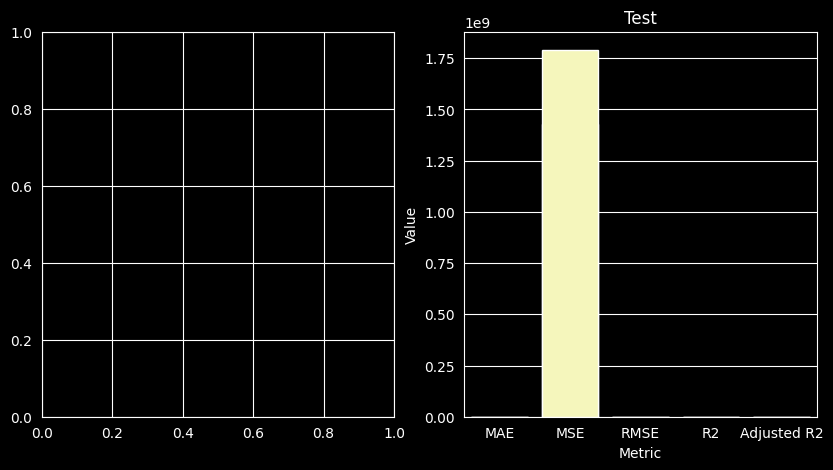

In [43]:
linear_pipline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(k=10)),
    ('regressor', LinearRegression())
])

linear_pipline.set_params(**linear_study.best_params)

_ , linear_score = judge(linear_pipline)

linear_score

# Ridge

In [ ]:
from sklearn.linear_model import Ridge


def ridge_study(trial, X, y):
    # Hyperparameter to tune
    alpha = trial.suggest_float("alpha", 1e-4, 100.0, log=True)

    # Pipeline (scaling + ridge)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=alpha))
    ])

    # Cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        pipe,
        X,
        y,
        cv=cv,
        scoring='neg_mean_squared_error'
    ).mean()

    return score  # maximize negative MSE

# Create and run study
study = optuna.create_study(direction='maximize')
study.optimize(
    lambda trial: ridge_study(trial, train_x, train_y),
    n_trials=50,
    show_progress_bar=True
)

ridge_study.best_